# Notebook 05: Validación externa sobre un segundo dataset
## 5. Validación externa con un segundo dataset

**Objetivo**: comprobar que la metodología desarrollada para el dataset de Caja España no es un resultado particular de esos datos, sino un procedimiento que generaliza a otros problemas de credit scoring. Para ello se replica el estudio completo sobre un dataset distinto, ampliamente utilizado en la literatura.

**Dataset**: *Default of Credit Card Clients* (Taiwán, 2005), publicado por Yeh y Lien (2009) y disponible en el repositorio UCI / OpenML. Contiene 30.000 clientes de tarjeta de crédito descritos por 23 variables (límite de crédito, datos sociodemográficos, historial de pagos y de facturación), con la variable objetivo *default* (impago en el mes siguiente).

Se aplica el mismo procedimiento que en los notebooks 02 a 04: partición estratificada 50/25/25, corrección del desbalanceo mediante ponderación, y comparación de la Regresión Logística (cruda y con WoE) frente a Random Forest y XGBoost mediante AUC, KS y Gini.

## 5.1 Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from optbinning import BinningProcess
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 5.2 Carga del dataset y análisis exploratorio breve

Se carga el dataset, previamente descargado del repositorio OpenML y almacenado en *data/taiwan_credit.csv*, y se examina su tamaño y el grado de desbalanceo de la variable objetivo.

Dimensiones: 30,000 clientes x 23 variables
Tasa de impago (default): 22.1%
Valores nulos: 0


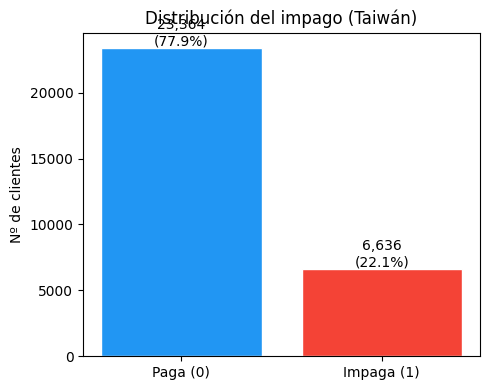

In [2]:
df = pd.read_csv("../data/taiwan_credit.csv")
TARGET = "default"
FEATURES = [c for c in df.columns if c != TARGET]

print(f"Dimensiones: {df.shape[0]:,} clientes x {len(FEATURES)} variables")
print(f"Tasa de impago (default): {df[TARGET].mean():.1%}")
print(f"Valores nulos: {int(df.isna().sum().sum())}")

dist = df[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Paga (0)", "Impaga (1)"], dist.values, color=["#2196F3", "#F44336"], edgecolor="white")
ax.set_ylabel("Nº de clientes"); ax.set_title("Distribución del impago (Taiwán)")
for i, v in enumerate(dist.values):
    ax.text(i, v + 200, f"{v:,}\n({v/len(df):.1%})", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("../reports/figures/05_taiwan_target.png", dpi=150, bbox_inches="tight")
plt.show()

El desbalanceo (22,1% de impagos) es **moderado**, frente al desbalanceo extremo del dataset de Caja España (7,5%). Esta diferencia tiene una consecuencia metodológica directa: mientras que en Caja España fue necesario un oversampling estratificado para que la clase minoritaria fuese visible, aquí basta con **ponderar las clases** durante el entrenamiento. Es la primera muestra de adaptación del método a las características de los datos.

## 5.3 Partición y ponderación de clases

Se divide la muestra en train / validación / test (50% / 25% / 25%) de forma estratificada, igual que en el estudio principal.

El reto del desbalanceo es que hay muchos más clientes que pagan que clientes que impagan (en torno a 3,5 buenos por cada malo). Si se entrenara sin corregir esa proporción, al modelo le bastaría con acertar a la clase mayoritaria para reducir su error global, de modo que prestaría poca atención a los impagadores, que son precisamente los que interesa detectar.

La ponderación corrige ese sesgo asignando a cada cliente impagador un peso igual a la razón entre buenos y malos del conjunto de entrenamiento (aquí 3,52), mientras que cada cliente bueno mantiene un peso de 1. Así, un fallo sobre un impagador penaliza 3,52 veces más que un fallo sobre un buen cliente, lo que iguala el peso total de ambas clases en la función de pérdida que el modelo minimiza: aunque los impagadores sean menos numerosos, en conjunto cuentan lo mismo. Es la alternativa al oversampling empleado en Caja España: en lugar de duplicar observaciones de la clase minoritaria, se aumenta la importancia de cada una.

In [3]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.50, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

peso = (y_train == 0).sum() / (y_train == 1).sum()
w_train = np.where(y_train == 0, 1.0, peso)

print(f"Train: {len(X_train):,} | Validación: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Peso aplicado a los impagadores: {peso:.2f}")

Train: 15,000 | Validación: 7,500 | Test: 7,500
Peso aplicado a los impagadores: 3.52


## 5.4 Modelización

Se entrenan los mismos cuatro modelos del estudio principal, cada uno con su preprocesamiento idóneo: la Regresión Logística cruda con estandarización; la Regresión Logística con la transformación WoE; y los modelos no lineales Random Forest y XGBoost sobre las variables originales. Todos reciben el peso de clase.

In [4]:
def discriminacion(y, prob):
    auc = roc_auc_score(y, prob)
    fpr, tpr, _ = roc_curve(y, prob)
    return auc, (tpr - fpr).max(), 2 * auc - 1

resultados = {}
probas = {}

# 1) Regresión Logística cruda (estandarizada)
rl = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=SEED))
rl.fit(X_train, y_train, logisticregression__sample_weight=w_train)
probas["RL base"] = rl.predict_proba(X_test)[:, 1]

# 2) Regresión Logística + WoE
binning = BinningProcess(FEATURES)
binning.fit(X_train.values, y_train.values)
Wtr, Wte = binning.transform(X_train.values, metric="woe"), binning.transform(X_test.values, metric="woe")
rl_woe = LogisticRegression(max_iter=5000, random_state=SEED)
rl_woe.fit(Wtr, y_train, sample_weight=w_train)
probas["RL + WoE"] = rl_woe.predict_proba(Wte)[:, 1]

# 3) Random Forest
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, max_features="sqrt", random_state=SEED, n_jobs=1)
rf.fit(X_train, y_train, sample_weight=w_train)
probas["Random Forest"] = rf.predict_proba(X_test)[:, 1]

# 4) XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8,
                    colsample_bytree=0.8, eval_metric="logloss", random_state=SEED, n_jobs=1, verbosity=0)
xgb.fit(X_train, y_train, sample_weight=w_train)
probas["XGBoost"] = xgb.predict_proba(X_test)[:, 1]

for nombre, p in probas.items():
    auc, ks, gini = discriminacion(y_test, p)
    resultados[nombre] = {"AUC": round(auc, 4), "KS": round(ks, 4), "Gini": round(gini, 4)}

tabla = pd.DataFrame(resultados).T
print(tabla.to_string())

                  AUC      KS    Gini
RL base        0.7233  0.3827  0.4465
RL + WoE       0.7714  0.4255  0.5428
Random Forest  0.7800  0.4321  0.5600
XGBoost        0.7811  0.4378  0.5622


La tabla reproduce, sobre un dataset completamente distinto, el mismo orden de modelos que en Caja España. La Regresión Logística cruda parte de un AUC de 0,7233; al aplicar el WoE sube a 0,7714, lo que confirma de nuevo que esa transformación es la que permite al modelo lineal expresar su capacidad. Los modelos no lineales quedan por encima, con XGBoost (0,7811) otra vez como el más discriminante, seguido muy de cerca por Random Forest (0,7800).

Los valores absolutos son sensiblemente más bajos que en Caja España (AUC de 0,72-0,78 frente a 0,97-0,99), no porque el método funcione peor, sino porque el dataset de Taiwán es un problema de credit scoring intrínsecamente más difícil, con variables menos predictivas. La lectura completa de estos resultados y su significado para la validación de la metodología se desarrolla en la sección 5.6.

## 5.5 Comparativa y curvas ROC

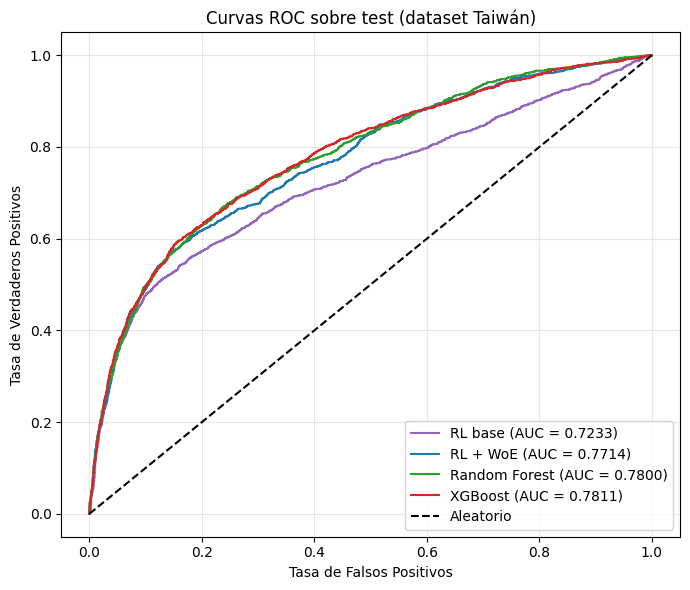

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
colores = {"RL base": "#9467bd", "RL + WoE": "#1f77b4", "Random Forest": "#2ca02c", "XGBoost": "#d62728"}
for nombre, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})", color=colores[nombre])
ax.plot([0, 1], [0, 1], "k--", label="Aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos"); ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC sobre test (dataset Taiwán)")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/05_taiwan_ROC.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.6 Conclusión de la validación externa

El estudio replicado sobre el dataset de Taiwán reproduce, sobre datos completamente distintos, los mismos patrones observados en Caja España:

1. **El nivel de discriminación depende del problema, no del método.** Los AUC obtenidos (en torno a 0,72-0,78) son muy inferiores a los de Caja España (0,97-0,99), lo que refleja que el dataset de Taiwán es un problema de credit scoring intrínsecamente más difícil, con variables menos predictivas. Estos valores son coherentes con los publicados en la literatura para este dataset.

2. **La transformación WoE recupera la Regresión Logística.** El AUC de la Regresión Logística pasa de 0,7233 (variables crudas) a 0,7714 con WoE, una mejora del mismo signo y magnitud relativa que la observada en Caja España. Se confirma que el WoE es el ingrediente que permite al modelo lineal expresar su capacidad.

3. **Los modelos de machine learning vuelven a imponerse.** Random Forest (0,7800) y XGBoost (0,7811) superan de nuevo a la Regresión Logística, y XGBoost es otra vez el modelo más discriminante, igual que en el estudio principal.

La conclusión es que el procedimiento construido en este trabajo (corrección del desbalanceo, partición estratificada, comparación de modelos lineales y no lineales con métricas de credit scoring) **no está sobreajustado al caso de Caja España**, sino que constituye una metodología general y reproducible, capaz de adaptarse a las particularidades de cada conjunto de datos, como el distinto grado de desbalanceo que exigió aquí una ponderación de clases en lugar de un oversampling.